# Problem Statement:
## Use Euler's Method to solve the differential equation  
$$\frac{dx}{dt} = -x^3 + \sin(t)$$  
with initial condition $x = 0$ at $t = 0$.

*Source: Mark Newman, Computational Physics (1st Edition)*


# Version 1. 4th-Order Runge-Kutta Baseline Implementation (Newman, 2013)
Source: Mark Newman, *Computational Physics (1st Edition)*, https://websites.umich.edu/~mejn/cp2/programs/rk4.py

The code in the following cell is taken directly from Newman's website linked above.

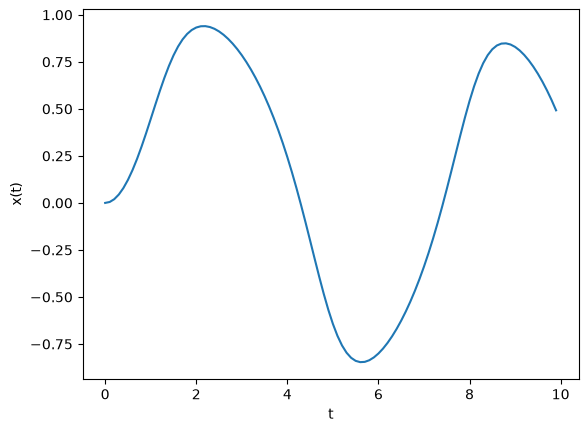

In [4]:
from math import sin
from numpy import arange
import matplotlib.pyplot as plt

def f(x,t):
    return -x**3 + sin(t)

a = 0.0
b = 10.0
N = 100
h = (b-a)/N

tpoints = arange(a,b,h)
xpoints = []
x = 0.0

for t in tpoints:
    xpoints.append(x)
    k1 = h*f(x,t)
    k2 = h*f(x+0.5*k1,t+0.5*h)
    k3 = h*f(x+0.5*k2,t+0.5*h)
    k4 = h*f(x+k3,t+h)
    x += (k1+2*k2+2*k3+k4)/6

plt.plot(tpoints,xpoints)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.show()

# Version 2: RK4 using Numba

In [ ]:
from typing import Tuple
import matplotlib.pyplot as plt
import math
import numpy as np
import numba

@numba.njit
def f_numba(x: float, t: float) -> float:
    """RHS of ODE dx/dt = f(x, t)"""
    return -x**3 + math.sin(t)

@numba.njit
def rk4_numba(
    t_start: float,
    t_end: float,
    n_steps: int,
    x0_batch: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    RK4 method that uses JIT compilation via Numba. Allows for batch trajectory
    calculation across multiple initial conditions. The array of multiple initial
    conditions is assumed to be supplied by the user.

    We're assuming an ODE with function f(x, t) = -x^3 + sin(t).

    Returns Tuple[time points array, 2D array for all trajectories x(t)].
    """

    # Calculate step size manually because Numba doesn't support retstep=True
    # in np.linspace. Numba also doesn't like endpoint=False
    h = (t_end - t_start) / n_steps
    t_points = np.linspace(t_start, t_end - h, n_steps)

    # Pre-allocate 2D grid for multiple trajectories
    num_trajectories = len(x0_batch)
    x_grid = np.empty((n_steps, num_trajectories), dtype=np.float64)

    # Need to ensure x0_batch is passed in with dtype=np.float64
    x = x0_batch.copy()

    for i in range(n_steps):
        x_grid[i] = x
        t = t_points[i]
        
        for j in range(num_trajectories):
            xj = x[j]

            k1 = h * f_numba(xj, t)
            k2 = h * f_numba(xj + 0.5 * k1, t + 0.5 * h)
            k3 = h * f_numba(xj + 0.5 * k2, t + 0.5 * h)
            k4 = h * f_numba(xj + k3, t + h)

            x[j] = xj + (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0

    return t_points, x_grid

# Python wrapper to handle default arguments before handing off to JIT
# Numba can't handle x0_batch: np.ndarray | None = None
def solve_rk4_numba(
    t_start: float = 0.0,
    t_end: float = 10.0,
    n_steps: int = 100,
    x0_batch: np.ndarray | None = None,
) -> Tuple[np.ndarray, np.ndarray]:

    if x0_batch is None:
        x0_batch = np.array([0.0, 0.5, 1.0, 1.5], dtype=np.float64)
    else:
        x0_batch = np.asarray(x0_batch, dtype=np.float64)

    return rk4_numba(t_start, t_end, n_steps, x0_batch)

# Plotting
if __name__ == "__main__":

    plot2_init = np.array([-2.0, -1.0, 0.0, 0.5, 2.0]) #user-defined initial conditions
    t_pts_plot2, x_grid_plot2 = solve_rk4_numba(x0_batch=plot2_init)
    fig2, ax2 = plt.subplots(figsize=(9, 5))

    # x_grid has shape (n_steps, num_trajectories)
    # We loop over each trajectory to give each its own color, label and legend entry.
    for i, x0 in enumerate(plot2_init):
        ax2.plot(t_pts_plot2, x_grid_plot2[:, i], label=f"$x_0 = {x0}$", linewidth=1.8)

    ax2.set_title(f"Numba RK4 Method ({len(plot2_init)} Trajectories, N={len(t_pts_plot2)})")
    ax2.set_xlabel("Time (t)")
    ax2.set_ylabel("State x(t)")
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.legend(title="Initial State", loc="upper right")

    plt.tight_layout()
    plt.show()